# 02 — Preprocessing
**VitalTracker | PhysioNet BIDMC Dataset**

Goal: Clean the raw BIDMC data, normalise it, and produce sliding-window arrays
ready for LSTM Autoencoder training.

Output files saved to Google Drive:
- `data/processed/X_train.npy` — training windows (normal data only)
- `data/processed/X_test.npy`  — test windows
- `data/processed/test_meta.csv` — patient IDs and timestamps for test windows
- `models/lstm_autoencoder/scaler.pkl` — fitted MinMaxScaler

### Setup

In [2]:
import pandas as pd
import numpy as np
import glob
import os
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit

# ── Paths ────────────────────────────────────────────────────
BIDMC_PATH      = '../data/raw/bidmc/bidmc_compiled_numerics.csv'
PROCESSED_PATH  = '../data/processed/'
MODEL_PATH      = '../models/lstm_autoencoder/'

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(MODEL_PATH,     exist_ok=True)

# ── Window config ─────────────────────────────────────────────
WINDOW_SIZE     = 60      # seconds (1Hz = 60 samples per window)
STEP_SIZE       = 1       # stride — 1 step overlap for max data usage
FEATURES        = ['HR', 'SpO2']

# ── Validation thresholds (must match fog/ingestion/mqtt_subscriber.py) ──
HR_MIN, HR_MAX      = 30, 220
SPO2_MIN, SPO2_MAX  = 70, 100

# ── Train/test split ──────────────────────────────────────────
TEST_SIZE       = 0.2     # 20% of patients held out for testing
RANDOM_STATE    = 42

print('Config set.')
print(f'  Window size : {WINDOW_SIZE}s')
print(f'  Step size   : {STEP_SIZE}s')
print(f'  Features    : {FEATURES}')
print(f'  Train/test  : {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)} split by patient')

Config set.
  Window size : 60s
  Step size   : 1s
  Features    : ['HR', 'SpO2']
  Train/test  : 80/20 split by patient


### Data 

In [4]:
raw_data = pd.read_csv(BIDMC_PATH)

raw_data.head()

,Time,HR,SpO2,patient_id
0,0,94.0,97.0,1
1,1,94.0,97.0,1
2,2,94.0,97.0,1
3,3,92.0,97.0,1
4,4,93.0,97.0,1


### Cleaning

In [5]:
df = raw_data.copy()
initial_count = len(df)

# ── Step 1: Drop nulls ────────────────────────────────────────
df = df.dropna(subset=['HR', 'SpO2'])
after_null = len(df)
print(f'Dropped (nulls)          : {initial_count - after_null}')

# ── Step 2: Drop physiologically impossible values ────────────
mask_valid = (
    (df['HR']   >= HR_MIN)   & (df['HR']   <= HR_MAX) &
    (df['SpO2'] >= SPO2_MIN) & (df['SpO2'] <= SPO2_MAX)
)
df = df[mask_valid]
after_range = len(df)
print(f'Dropped (out of range)   : {after_null - after_range}')

# ── Step 3: Drop patients with very short recordings ──────────
# Need at least 2x WINDOW_SIZE seconds to produce any windows
MIN_RECORDS = WINDOW_SIZE * 2
patient_counts = df.groupby('patient_id').size()
valid_patients = patient_counts[patient_counts >= MIN_RECORDS].index
df = df[df['patient_id'].isin(valid_patients)]
after_short = len(df)
print(f'Dropped (short patients) : {after_range - after_short}')
print(f'Patients remaining       : {df["patient_id"].nunique()}')

# ── Final count ───────────────────────────────────────────────
total_dropped = initial_count - len(df)
print(f'\nTotal dropped  : {total_dropped} ({total_dropped/initial_count*100:.2f}%)')
print(f'Remaining rows : {len(df):,}')

Dropped (nulls)          : 132
Dropped (out of range)   : 0
Dropped (short patients) : 0
Patients remaining       : 53

Total dropped  : 132 (0.52%)
Remaining rows : 25,361


### Train test split

In [6]:
patients = df['patient_id'].unique()
np.random.seed(RANDOM_STATE)
np.random.shuffle(patients)

n_test  = max(1, int(len(patients) * TEST_SIZE))
n_train = len(patients) - n_test

train_patients = patients[:n_train]
test_patients  = patients[n_train:]

df_train = df[df['patient_id'].isin(train_patients)].copy()
df_test  = df[df['patient_id'].isin(test_patients)].copy()

print(f'Train patients : {len(train_patients)} ({len(df_train):,} rows)')
print(f'Test patients  : {len(test_patients)}  ({len(df_test):,} rows)')
print(f'\nTest patient IDs : {sorted(test_patients.tolist())}')

Train patients : 43 (20,653 rows)
Test patients  : 10  (4,708 rows)

Test patient IDs : [8, 15, 19, 21, 23, 29, 39, 43, 52, 53]


### Normalization

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit ONLY on training data
scaler.fit(df_train[FEATURES])

# Transform both sets
df_train_scaled = df_train.copy()
df_test_scaled  = df_test.copy()

df_train_scaled[FEATURES] = scaler.transform(df_train[FEATURES])
df_test_scaled[FEATURES]  = scaler.transform(df_test[FEATURES])

# Save scaler — needed at inference time in fog/model/inference.py
scaler_path = os.path.join(MODEL_PATH, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler saved to : {scaler_path}')

# Verify scale ranges
print(f'\nScaler min  : HR={scaler.data_min_[0]:.1f}, SpO2={scaler.data_min_[1]:.1f}')
print(f'Scaler max  : HR={scaler.data_max_[0]:.1f}, SpO2={scaler.data_max_[1]:.1f}')
print(f'\nScaled train range (should be 0-1):')
print(df_train_scaled[FEATURES].describe().round(3))

Scaler saved to : ../models/lstm_autoencoder/scaler.pkl

Scaler min  : HR=44.0, SpO2=83.0
Scaler max  : HR=139.0, SpO2=100.0

Scaled train range (should be 0-1):
              HR       SpO2
count  20653.000  20653.000
mean       0.466      0.806
std        0.123      0.200
min        0.000      0.000
25%        0.389      0.706
50%        0.463      0.882
75%        0.516      0.941
max        1.000      1.000


### Sliding Window Generation

Each window is 60 seconds of HR + SpO2 readings → shape (60, 2).  
Windows are generated **per patient** so no window spans two patients.

In [8]:
def create_windows(df_scaled, window_size=WINDOW_SIZE, step=STEP_SIZE):
    """
    Creates sliding windows per patient.
    Returns:
        X    : np.array shape (n_windows, window_size, n_features)
        meta : list of dicts with patient_id and start_time per window
    """
    X    = []
    meta = []

    for pid, group in df_scaled.groupby('patient_id'):
        group = group.reset_index(drop=True)
        values = group[FEATURES].values   # shape (n_samples, 2)

        for start in range(0, len(values) - window_size + 1, step):
            end    = start + window_size
            window = values[start:end]
            X.append(window)
            meta.append({
                'patient_id' : pid,
                'start_idx'  : start,
                'end_idx'    : end,
                'start_time' : group['Time'].iloc[start] if 'Time' in group.columns else start,
            })

    return np.array(X, dtype=np.float32), meta


print('Generating training windows...')
X_train, train_meta = create_windows(df_train_scaled)

print('Generating test windows...')
X_test, test_meta = create_windows(df_test_scaled)

print(f'\nX_train shape : {X_train.shape}  (windows, timesteps, features)')
print(f'X_test shape  : {X_test.shape}')
print(f'\nMemory usage  : X_train={X_train.nbytes/1e6:.1f}MB, X_test={X_test.nbytes/1e6:.1f}MB')

Generating training windows...
Generating test windows...

X_train shape : (18116, 60, 2)  (windows, timesteps, features)
X_test shape  : (4118, 60, 2)

Memory usage  : X_train=8.7MB, X_test=2.0MB


### Verify Window Quality

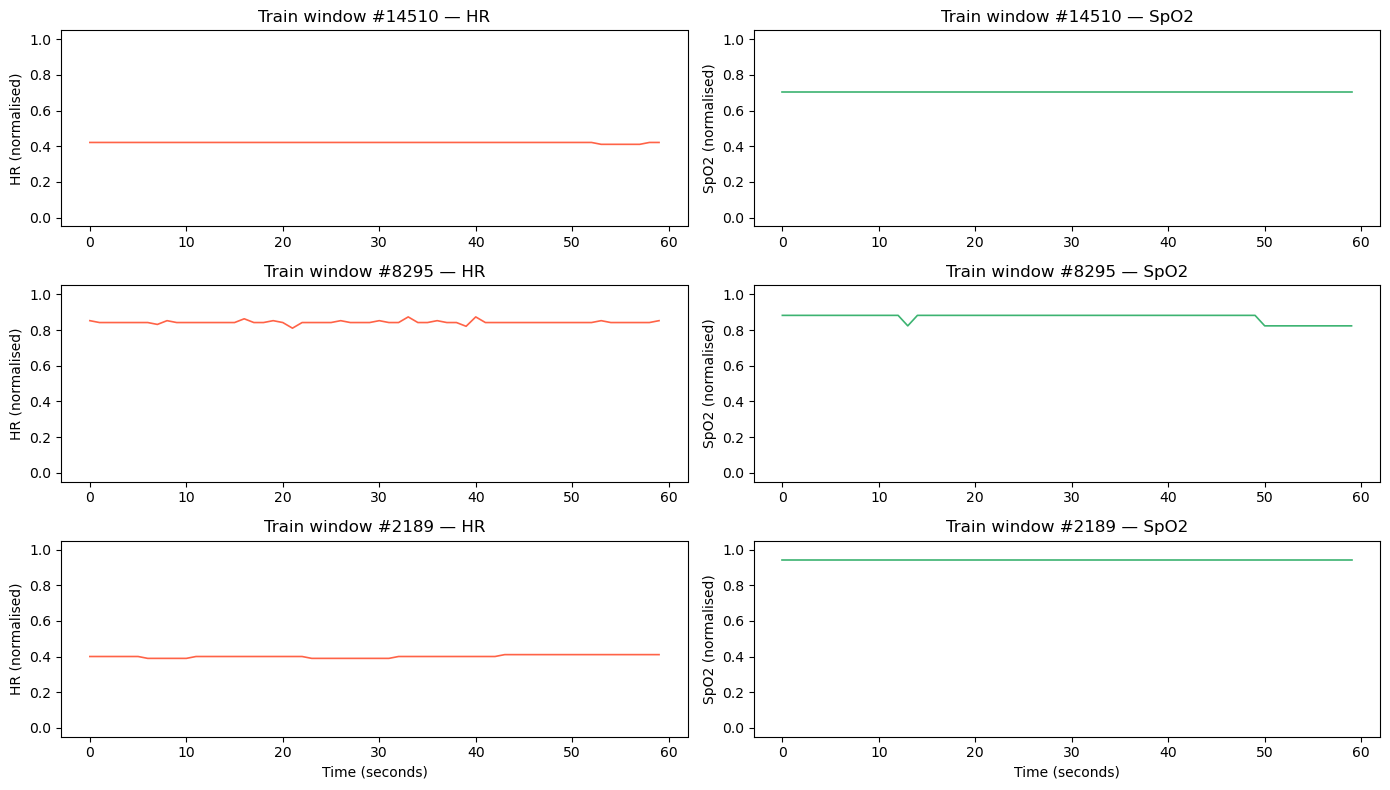

X_train value range : [0.0000, 1.0000]  (should be ~0 to 1)
X_test  value range : [0.1789,  1.0000]
NaN in X_train      : 0
NaN in X_test       : 0


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
sample_idxs = np.random.choice(len(X_train), 3, replace=False)

for row, idx in enumerate(sample_idxs):
    window = X_train[idx]   # shape (60, 2)
    t = np.arange(WINDOW_SIZE)

    axes[row, 0].plot(t, window[:, 0], color='tomato', linewidth=1.2)
    axes[row, 0].set_ylabel('HR (normalised)')
    axes[row, 0].set_ylim(-0.05, 1.05)
    axes[row, 0].set_title(f'Train window #{idx} — HR')

    axes[row, 1].plot(t, window[:, 1], color='mediumseagreen', linewidth=1.2)
    axes[row, 1].set_ylabel('SpO2 (normalised)')
    axes[row, 1].set_ylim(-0.05, 1.05)
    axes[row, 1].set_title(f'Train window #{idx} — SpO2')

for ax in axes[-1]:
    ax.set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

# Value range check
print(f'X_train value range : [{X_train.min():.4f}, {X_train.max():.4f}]  (should be ~0 to 1)')
print(f'X_test  value range : [{X_test.min():.4f},  {X_test.max():.4f}]')
print(f'NaN in X_train      : {np.isnan(X_train).sum()}')
print(f'NaN in X_test       : {np.isnan(X_test).sum()}')

### Save Processed Arrays

In [10]:
# Save numpy arrays
np.save(os.path.join(PROCESSED_PATH, 'X_train.npy'), X_train)
np.save(os.path.join(PROCESSED_PATH, 'X_test.npy'),  X_test)

# Save test metadata (needed in evaluation notebook to trace anomalies back to patients)
test_meta_df = pd.DataFrame(test_meta)
test_meta_df.to_csv(os.path.join(PROCESSED_PATH, 'test_meta.csv'), index=False)

# Save train/test patient ID split for reproducibility
split_info = {
    'train_patients' : sorted(train_patients.tolist()),
    'test_patients'  : sorted(test_patients.tolist()),
    'window_size'    : WINDOW_SIZE,
    'step_size'      : STEP_SIZE,
    'features'       : FEATURES,
    'random_state'   : RANDOM_STATE,
    'scaler'         : 'MinMaxScaler',
    'scaler_fit_on'  : 'train only',
}

import json
with open(os.path.join(MODEL_PATH, 'config.json'), 'w') as f:
    json.dump(split_info, f, indent=2)

print('Files saved:')
print(f'  {PROCESSED_PATH}X_train.npy     → {X_train.shape}')
print(f'  {PROCESSED_PATH}X_test.npy      → {X_test.shape}')
print(f'  {PROCESSED_PATH}test_meta.csv   → {len(test_meta_df)} rows')
print(f'  {MODEL_PATH}scaler.pkl')
print(f'  {MODEL_PATH}config.json')

Files saved:
  ../data/processed/X_train.npy     → (18116, 60, 2)
  ../data/processed/X_test.npy      → (4118, 60, 2)
  ../data/processed/test_meta.csv   → 4118 rows
  ../models/lstm_autoencoder/scaler.pkl
  ../models/lstm_autoencoder/config.json


### Preprocessing Summary

In [12]:
print('=' * 55)
print('  PREPROCESSING SUMMARY')
print('=' * 55)
print(f'  Raw rows loaded        : {len(raw_data):,}')
print(f'  After null drop        : {len(raw_data.dropna(subset=["HR","SpO2"])):,}')
print(f'  After range filter     : {len(df):,}')
print(f'  Train rows             : {len(df_train):,} ({len(train_patients)} patients)')
print(f'  Test rows              : {len(df_test):,}  ({len(test_patients)} patients)')
print()
print(f'  Window size            : {WINDOW_SIZE}s')
print(f'  Step size              : {STEP_SIZE}s')
print(f'  X_train windows        : {X_train.shape[0]:,}  shape {X_train.shape}')
print(f'  X_test windows         : {X_test.shape[0]:,}   shape {X_test.shape}')
print()
print(f'  Scaler                 : MinMaxScaler fit on train only')
print(f'  HR scale range         : [{scaler.data_min_[0]:.1f}, {scaler.data_max_[0]:.1f}] bpm → [0, 1]')
print(f'  SpO2 scale range       : [{scaler.data_min_[1]:.1f}, {scaler.data_max_[1]:.1f}]% → [0, 1]')

  PREPROCESSING SUMMARY
  Raw rows loaded        : 25,493
  After null drop        : 25,361
  After range filter     : 25,361
  Train rows             : 20,653 (43 patients)
  Test rows              : 4,708  (10 patients)

  Window size            : 60s
  Step size              : 1s
  X_train windows        : 18,116  shape (18116, 60, 2)
  X_test windows         : 4,118   shape (4118, 60, 2)

  Scaler                 : MinMaxScaler fit on train only
  HR scale range         : [44.0, 139.0] bpm → [0, 1]
  SpO2 scale range       : [83.0, 100.0]% → [0, 1]
